<a href="https://colab.research.google.com/github/PhoebeJS/casa0018/blob/main/Week3/CASA0018_3_3_Cats_v_Dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Training with a Larger Dataset - Cats and Dogs

> This lab is loosely based on one of the TensorFlow ‘Zero to Hero’ tutorials to create a model to recognize images of cats and dogs based on a previous Kaggle competition. There is a supporting video at: https://youtu.be/nq7_ZYJPWf0?t=141


Overfitting can be a problem when training on a small dataset. Overfitting means the network 'learns' the training dataset and therefore performs poorly when subjected to unseen data. In this lab you'll look at a real dataset and see the effects of overfitting and how to combat it. The training data set can be found in the following folder:

https://liveuclac-my.sharepoint.com/:f:/g/personal/ucfnmld_ucl_ac_uk/IgAhkP-D4Q_rRJKpJdJrmXK8AaSt67_3TvTCvAAEfjPO2yk


Download the zip file to your laptop. Then use the left hand panel of colab to upload the zip file to the 'tmp' directory - the upload may take a minute or two so be patient.

In [1]:
import os        # For interacting with the file system
import zipfile
import random    # For shuffling
import tensorflow as tf
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from shutil import copyfile # For copying files

First perform some clean up from previous runs

In [5]:
!rm -r /tmp/cats-v-dogs
!rm -r /tmp/PetImages
!rm -f /tmp/model.keras

rm: cannot remove '/tmp/cats-v-dogs': No such file or directory
rm: cannot remove '/tmp/PetImages': No such file or directory


In [6]:
from pathlib import Path
local_zip = '/tmp/cats-and-dogs.zip'
zip_file = Path(local_zip)
if zip_file.is_file():
  zip_ref   = zipfile.ZipFile(local_zip, 'r')
  zip_ref.extractall('/tmp')
  zip_ref.close()


In [7]:
print(len(os.listdir('/tmp/PetImages/Cat/'))) # prints the length of the list directory
print(len(os.listdir('/tmp/PetImages/Dog/')))

# Expected Output:
# 5200
# 5200

5200
5200


In [8]:
# Try Except lets you test a code block for errors (except specifically lets you handle the error)
try:
    os.mkdir('/tmp/cats-v-dogs')               # os.mkdir() creates a directory & if that directory already exists, produces an error
    os.mkdir('/tmp/cats-v-dogs/training')
    os.mkdir('/tmp/cats-v-dogs/testing')
    os.mkdir('/tmp/cats-v-dogs/training/cats')
    os.mkdir('/tmp/cats-v-dogs/training/dogs')
    os.mkdir('/tmp/cats-v-dogs/testing/cats')
    os.mkdir('/tmp/cats-v-dogs/testing/dogs')
except OSError: # OSError is a built-in exception in python & serves as the error class for the os module
                # OS module is raised when an os specific system function returns a system-related error
    pass    # Pass says to skip this line and do nothing

In [9]:
def split_data(SOURCE, TRAINING, TESTING, SPLIT_SIZE):
    # Define a function called split_data
    # SOURCE: directory containing all original images
    # TRAINING: directory where training images will be copied
    # TESTING: directory where testing images will be copied
    # SPLIT_SIZE: proportion of data to use for training (e.g. 0.8)

    files = []
    # Create an empty list to store valid filenames

    for filename in os.listdir(SOURCE):
      # os.listdir(SOURCE) returns list of filenames in the source directory
      # we loop over each filename one by one

        file = SOURCE + filename
        # build the full file path (directory + filename)

        if os.path.getsize(file) > 0:
          # os.path.getsize(file) returns the file size in bytes
          # this checks that the file is NOT empty

            files.append(filename)
            # Add file names to list
        else:
            print(filename + " is zero length, so ignoring.")
            # Warn about corrupted file images

    training_length = int(len(files) * SPLIT_SIZE)
    # Number of images to put in the training set
    # len(files) = total number of valid images
    # Multiply by SPLIT_SIZE (e.g. 0.8), then convert to integer

    testing_length = int(len(files) - training_length)
    # Remaining images go into testing set

    shuffled_set = random.sample(files, len(files))
    # random.sample(list, n) returns a NEW shuffled list
    # This randomises the order so training/testing data is unbiased

    training_set = shuffled_set[0:training_length]
    # Slice the first chunk for training
    # [start : end] slicing syntax

    testing_set = shuffled_set[-testing_length:]
    # Slice the last chunk for testing
    # Negative index means "count from the end"

    for filename in training_set:
      # loop over each training image

        this_file = SOURCE + filename
        # Full path to the og image

        destination = TRAINING + filename
        # Where the image should be copied to

        copyfile(this_file, destination)
        # Copy the file (does not remove the og)

    for filename in testing_set:
      # Loop over each testing image
        this_file = SOURCE + filename
        destination = TESTING + filename
        copyfile(this_file, destination)

# These directory definitions are just string variables holding paths
CAT_SOURCE_DIR = "/tmp/PetImages/Cat/"
TRAINING_CATS_DIR = "/tmp/cats-v-dogs/training/cats/"
TESTING_CATS_DIR = "/tmp/cats-v-dogs/testing/cats/"
DOG_SOURCE_DIR = "/tmp/PetImages/Dog/"
TRAINING_DOGS_DIR = "/tmp/cats-v-dogs/training/dogs/"
TESTING_DOGS_DIR = "/tmp/cats-v-dogs/testing/dogs/"

split_size = .8 # 80% training, 20% testing

# Run the function created above twice - once for dogs & once for cats
split_data(CAT_SOURCE_DIR, TRAINING_CATS_DIR, TESTING_CATS_DIR, split_size)
split_data(DOG_SOURCE_DIR, TRAINING_DOGS_DIR, TESTING_DOGS_DIR, split_size)


In [10]:
print(len(os.listdir('/tmp/cats-v-dogs/training/cats/')))
print(len(os.listdir('/tmp/cats-v-dogs/training/dogs/')))
print(len(os.listdir('/tmp/cats-v-dogs/testing/cats/')))
print(len(os.listdir('/tmp/cats-v-dogs/testing/dogs/')))

# Expected output:
# 4160
# 4160
# 1040
# 1040

4160
4160
1040
1040


In [11]:
model = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(shape=(150, 150, 3)),
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['acc'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,183,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,207,457 (4.61 MB)

 Trainable params: 1,207,457 (4.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:

TRAINING_DIR = "/tmp/cats-v-dogs/training/"
train_datagen = ImageDataGenerator(rescale=1.0/255.)
# ImageDataGenerator prepares images for training
# rescale=1.0/255. rescales pixel values from [0, 255] → [0, 1]

train_generator = train_datagen.flow_from_directory(TRAINING_DIR,
                                                    # Reads images from subfolders in TRAINING_DIR
                                                    # Folder names become class labels automatically

                                                    class_mode='binary',
                                                    # Binary classification: 0 or 1 (cat vs dog)

                                                    batch_size=32,
                                                    # Model sees 32 images at a time during training

                                                    target_size=(150, 150)) # every image is resized to 150x150 pixels


VALIDATION_DIR = "/tmp/cats-v-dogs/testing/"
validation_datagen = ImageDataGenerator(rescale=1.0/255.)
validation_generator = validation_datagen.flow_from_directory(VALIDATION_DIR,
                                                              class_mode='binary',
                                                              batch_size=32,
                                                              target_size=(150, 150))

# Expected Output:
# Found 8320 images belonging to 2 classes.
# Found 2080 images belonging to 2 classes.

Found 8320 images belonging to 2 classes.
Found 2080 images belonging to 2 classes.


In [13]:
# Note that this may take some time.
history = model.fit(train_generator, epochs=10, validation_data=validation_generator)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


260/260 ━━━━━━━━━━━━━━━━━━━━ 25s 75ms/step - acc: 0.5821 - loss: 0.6647 - val_acc: 0.7462 - val_loss: 0.5353
Epoch 2/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 19s 72ms/step - acc: 0.7500 - loss: 0.5167 - val_acc: 0.7582 - val_loss: 0.5103
Epoch 3/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 18s 70ms/step - acc: 0.7958 - loss: 0.4294 - val_acc: 0.7918 - val_loss: 0.4567
Epoch 4/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - acc: 0.8348 - loss: 0.3605 - val_acc: 0.7976 - val_loss: 0.4356
Epoch 5/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 18s 67ms/step - acc: 0.8665 - loss: 0.3134 - val_acc: 0.8168 - val_loss: 0.4171
Epoch 6/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 19s 73ms/step - acc: 0.8984 - loss: 0.2515 - val_acc: 0.8072 - val_loss: 0.4596
Epoch 7/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 18s 69ms/step - acc: 0.9282 - loss: 0.1832 - val_acc: 0.8197 - val_loss: 0.4688
Epoch 8/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - acc: 0.9437 - loss: 0.1452 - val_acc: 0.8226 - val_loss: 0.5102
Epoch 9/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 18s 69ms/st

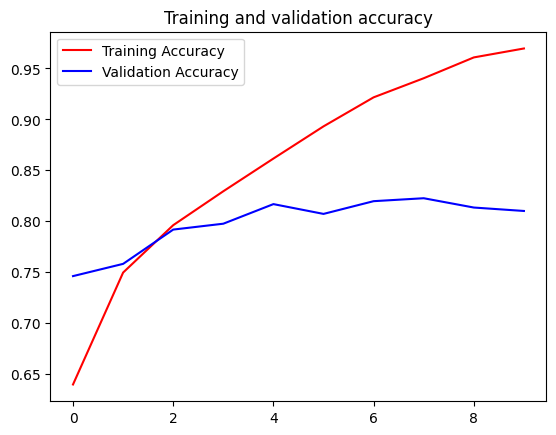

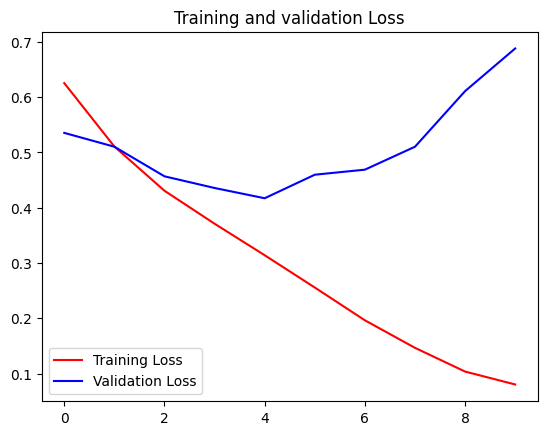

<Figure size 640x480 with 0 Axes>

In [14]:
%matplotlib inline

import matplotlib.pyplot as plt

#-----------------------------------------------------------
# Retrieve a list of list results on training and test data
# sets for each training epoch
#-----------------------------------------------------------
acc=history.history['acc']
val_acc=history.history['val_acc']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs=range(len(acc)) # Get number of epochs

#------------------------------------------------
# Plot training and validation accuracy per epoch
#------------------------------------------------
plt.plot(epochs, acc, 'r', label='Training Accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation Accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc=0)
plt.figure()

#------------------------------------------------
# Plot training and validation loss per epoch
#------------------------------------------------
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation Loss')
plt.legend(loc=0)
plt.figure()

plt.show()

# Desired output. Charts with training and validation metrics. No crash :)

If you inspect the Accuracy and Loss curves you will probably notice evidence of *overfitting* (where the network learns the training data set). You will notice that the training accuracy is too high and significantly better than the validation accuracy. And if you look at the loss curves the validation loss maybe increasing as the training progresses.

Use the following code to test out the model on a few images of cats and dogs that you have downloaded from the internet.


In [ ]:
# Here's a codeblock just for fun. You should be able to upload an image here
# and have it classified without crashing
import numpy as np
from google.colab import files
from keras.preprocessing import image

uploaded = files.upload()

for fn in uploaded.keys():

  # predicting images
  path = '/content/' + fn
  img = image.load_img(path, target_size=(150, 150))
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)

  images = np.vstack([x])
  classes = model.predict(images, batch_size=10)
  print(classes[0])
  print(classes)
  if classes[0]>0.5:
    print(fn + " is a dog")
  else:
    print(fn + " is a cat")

You may well find the model performs poorly at classifying images that it has not seen before - in other words it does not 'generalise' well, which is a classic sympton of model overfit.

To combat this overfitting we can adopt a number of measures, particularly data augmentation (to diversify the training data set) and regularisation (randomly dropping some connections for each training iteration). This should reduce the overfitting and increase the ability of the network to generalise (accurately classify unseen data).

The code below illustrates a modified model architecture that should be more resistant to overfitting.

In [15]:
model_2 = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(shape=(150, 150, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.2),
    # Here, Droupout(0.2) says to set 20% of the layer's activations to 0 during training with each path forward
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu', kernel_initializer='he_uniform'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_2.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['acc'])
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,401,921 (20.61 MB)

 Trainable params: 5,401,921 (20.61 MB)

 Non-trainable params: 0 (0.00 B)

Now we will add some data augmentation

In [16]:
 # augmentation shifts the image, which forces the model to respond as if its viewing window were moving,
 # teaching it that position shouldn’t define the class
train_datagen_2 = ImageDataGenerator(rescale=1.0/255.0,
                                     # Same pixel scaling as previously

                                     width_shift_range=0.1,
                                     # Random horizontal translation
                                     # Shift left or right by up to 10% or image width

                                     height_shift_range=0.1,
                                     # Random vertical translation
                                     # Shift up or down by up to 10% of image height

                                     horizontal_flip=True) # Randomly flip the image left/right (50% chance)
train_generator_2 = train_datagen_2.flow_from_directory(TRAINING_DIR, class_mode='binary', batch_size=32, target_size=(150, 150))


validation_datagen_2 = ImageDataGenerator(rescale=1.0/255.)
validation_generator_2 = validation_datagen.flow_from_directory(VALIDATION_DIR, class_mode='binary', batch_size=32, target_size=(150, 150))

Found 8320 images belonging to 2 classes.
Found 2080 images belonging to 2 classes.


Now train the new model. This may take a long time if you do not get allocated a GPU. Instead you can skip a [few steps](#scrollTo=45MhQH21bsBT&line=4&uniqifier=1) and use a model I trained earlier

In [17]:
history_2 = model_2.fit(train_generator_2, epochs=50, validation_data=validation_generator_2)

Epoch 1/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 71s 239ms/step - acc: 0.5220 - loss: 1.4600 - val_acc: 0.6091 - val_loss: 0.6810
Epoch 2/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 60s 231ms/step - acc: 0.5827 - loss: 0.6703 - val_acc: 0.6683 - val_loss: 0.6205
Epoch 3/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 60s 228ms/step - acc: 0.6394 - loss: 0.6345 - val_acc: 0.6995 - val_loss: 0.5826
Epoch 4/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 60s 231ms/step - acc: 0.6924 - loss: 0.5899 - val_acc: 0.7274 - val_loss: 0.5345
Epoch 5/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 61s 235ms/step - acc: 0.7250 - loss: 0.5435 - val_acc: 0.7538 - val_loss: 0.4964
Epoch 6/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 61s 234ms/step - acc: 0.7314 - loss: 0.5199 - val_acc: 0.7986 - val_loss: 0.4517
Epoch 7/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 61s 235ms/step - acc: 0.7683 - loss: 0.4874 - val_acc: 0.8014 - val_loss: 0.4397
Epoch 8/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 61s 235ms/step - acc: 0.7622 - loss: 0.4872 - val_acc: 0.8067 - val_loss: 0.4344
Epoch 9/50
260/260 ━━━━━━━━━━━━━

KeyboardInterrupt: 

In [ ]:
%matplotlib inline
#-----------------------------------------------------------
# Retrieve a list of list results on training and test data
# sets for each training epoch
#-----------------------------------------------------------
acc=history_2.history['acc']
val_acc=history_2.history['val_acc']
loss=history_2.history['loss']
val_loss=history_2.history['val_loss']

epochs=range(len(acc)) # Get number of epochs

#------------------------------------------------
# Plot training and validation accuracy per epoch
#------------------------------------------------
plt.plot(epochs, acc, 'r', label='Training Accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation Accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc=0)
plt.figure()

#------------------------------------------------
# Plot training and validation loss per epoch
#------------------------------------------------
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation Loss')
plt.legend(loc=0)
plt.figure()

plt.show()
plt.savefig('foo.png')


In [ ]:
model_2.save("/tmp/model.keras")

If you haven't got time to train the model, then you can upload a model I trained earlier using a GPU. This can be found at:

https://liveuclac-my.sharepoint.com/:f:/g/personal/ucfnmld_ucl_ac_uk/IgAhkP-D4Q_rRJKpJdJrmXK8AaSt67_3TvTCvAAEfjPO2yk


Upload the model to the 'tmp' folder as before.

In [ ]:
model_2 = tf.keras.models.load_model('/tmp/model_2.keras', compile=False)

In [ ]:
# Here's a codeblock just for fun. You should be able to upload an image here
# and have it classified without crashing
import numpy as np
from google.colab import files
from keras.preprocessing import image

uploaded = files.upload()

for fn in uploaded.keys():

  # predicting images
  path = '/content/' + fn
  img = image.load_img(path, target_size=(150, 150))
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)

  images = np.vstack([x])
  classes = model_2.predict(images, batch_size=10)
  print(classes[0])
  print(classes)
  if classes[0]>0.5:
    print(fn + " is a dog")
  else:
    print(fn + " is a cat")